<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/ANNs/blob/main/Notebooks/MLP_scratch.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#################################################
# Author: Wilfrido Gómez-Flores (Cinvestav)     #
# e-mail: wgomez@cinvestav.mx                   #
# Date:   february 2026                         #
# Subject:  Multi-layer perceptron from scratch #
#################################################

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Functions
sg  = lambda x: 1.0 / (1.0 + np.exp(-x)) # Sigmoid activation function
sm  = lambda x: np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True) # Softmax
cce = lambda t, z: -np.sum(t * np.log(z + np.finfo(float).eps), axis=1) # Categorical cross-entropy
bce = lambda t, z: -(t * np.log(z + np.finfo(float).eps) + (1.0 - t) * np.log(1.0 - (z + np.finfo(float).eps))) # Binary cross-entropy

#********************************************************************************
# Function to train MLP with one hidden layer
def train_mlp(X, Y, h, eta, l, epochMax):
    # X: feature data, matrix of size #samples x #features
    # Y: class labels, vector of with #samples elements
    # h: number of hidden neurons
    # l: regularization parameter
    # epochMax: number of training epochs
    nc = len(np.unique(Y)) # Number of classes
    n, d = X.shape
    if nc > 2: # Multiclass
        c = nc # C output nodes
        # Actual outputs in one-hot encoding
        grid = np.tile(np.arange(1, c + 1), (n, 1))
        tk = (Y.reshape(-1, 1) == grid).astype(float)
    else: # Two-class
        c = 1 # One output node
        tk = (Y == np.max(Y)).astype(float).reshape(-1, 1) # Ensure 0 and 1 labels
    # Add dummy inputs for the biases calculation
    unos = np.ones((n, 1))
    X = np.concatenate((unos, X), axis=1)
    # LeCun weights initialization
    rd = lambda a, b, s, t: a + (b - a) * np.random.rand(s, t)
    Wji = rd(-np.sqrt(3.0 / d), np.sqrt(3.0 / d), h, d + 1) # input-hidden layer weights
    Wkj = rd(-np.sqrt(3.0 / h), np.sqrt(3.0 / h), c, h + 1) # hidden-ouput layer weights
    # Training loop
    Jn = np.zeros(epochMax) # Array to save loss function
    for t in range(epochMax):
        # Shuffle data every epoch
        idx = np.random.permutation(n)
        X = X[idx, :]
        tk = tk[idx, :]
        # Feedforward step
        yj = sg(X @ Wji.T)  # Hidden layer response
        # Add dummy inputs
        yj = np.concatenate((np.ones((n, 1)), yj), axis=1)
        # Regularization (skipping the bias weight)
        L2 = (l / 2.0) * (np.sum(Wji[:, 1:]**2) + np.sum(Wkj[:, 1:]**2))
        if c > 1:
            # Output layer response with softmax
            zk = sm(yj @ Wkj.T)
            # Regularized categorical cross-entropy loss
            Jn[t] = np.mean(cce(tk, zk)) + L2
        else:
            # Output layer response with sigmoid
            zk = sg(yj @ Wkj.T)
            # Regularized binary cross-entropy loss
            Jn[t] = np.mean(bce(tk, zk)) + L2
        # Backpropagation step
        dk = zk - tk # delta k
        Dwkj = dk.T @ yj # Delta rule hidden-ouput
        dj = (dk @ Wkj) * (yj * (1.0 - yj)) # delta j
        Dwji = dj[:, 1 : h + 1].T @ X # Delta rule input-hidden
        # Weights update
        Wji = (1.0 - eta * l) * Wji - eta * Dwji # input-hidden
        Wkj = (1.0 - eta * l) * Wkj - eta * Dwkj # hidden-output
    return Wji, Wkj, Jn

#********************************************************************************
# Function to predict with MLP
def predict_mlp(X, Wji, Wkj):
    # X: feature data, matrix of size #samples x #features
    # Wji: weights input to hidden layers
    # Wkj: weights hidden to output layers
    nt = X_test.shape[0]
    yj = sg(np.column_stack([np.ones(nt), X_test]) @ Wji.T) # Hidden layer response
    yj = np.column_stack([np.ones(nt), yj]) # Add dummy variable foir bias
    if opt.lower() == 'bin':
        zk = sg(yj @ Wkj.T) # Output layer response with sigmoid
        Y_pred = zk >= 0.5 # Predicted class labels
    else:
        zk = sm(yj @ Wkj.T) # Output layer response with softmax
        Y_pred = np.argmax(zk, axis=1) # Predicted class labels by maximum probability
        Y_pred = Y_pred+1 # Natural numbers (1,2,...,c)
    return Y_pred, zk

In [ ]:
# Read CSV file with breast tumor morphological features
url='https://drive.google.com/file/d/10tilQVjF71MoVGqqM0ATZ8Q6KuwsoWZr/view?usp=drive_link'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url)

# Get data arrays
arr = df.to_numpy()
# Options: 'bin' is binary classification
#          'mul' is multiclass classification
opt = 'bin'
X = arr[:, :-2]
if opt.lower() == 'bin':
    Y = arr[:, -2]
    labs = ['Benign', 'Malignant'] # Pathological classes
elif opt.lower() == 'mul':
    Y = arr[:, -1]
    labs =['B2', 'B3', 'B4', 'B5'] # BI-RADS categories

In [ ]:
# Split data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2, stratify=Y)

# Normalize training data and apply same transformation to test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train MLP weights
epochMax = 1000 # Number of training epochs
hn = 20 # Number of hidden neurons
eta = 1e-4 # Learning rate
lam = 1e-6 # Regularization parameter
Wji, Wkj, J = train_mlp(X_train, Y_train, hn, eta, lam, epochMax)

# Predict with MLP
Y_pred, Y_prob = predict_mlp(X_test, Wji, Wkj)

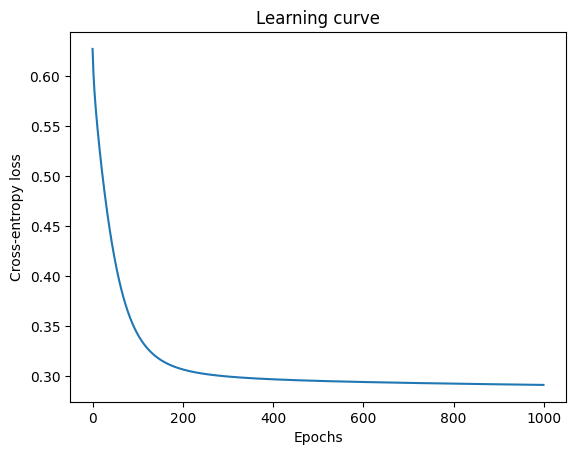


Accuracy: 0.883


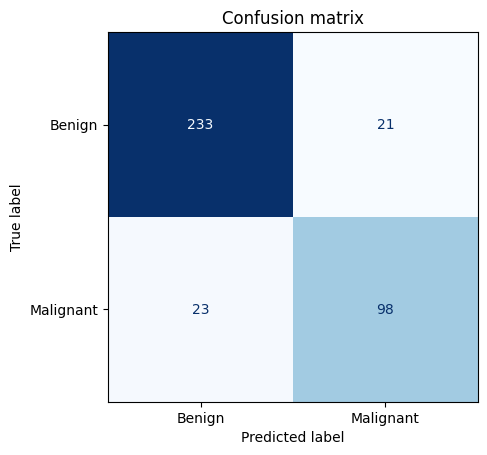

In [ ]:
# Learning curve
plt.figure()
plt.plot(np.arange(0, len(J)), J)
plt.xlabel('Epochs')
plt.ylabel('Cross-entropy loss')
plt.title('Learning curve')
plt.show()
print()

# Calculate accuracy
Y_test = Y_test.reshape(-1, 1) # Ensure that Y_test is a column vector
Y_pred = Y_pred.reshape(-1, 1) # Ensure that Y_pred is a column vector
ACC = np.mean(Y_pred == Y_test)
print(f"Accuracy: {ACC:.3f}")

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labs)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()